In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
    
    
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle


In [13]:
odir = "../ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_all.pickle", "rb") as f:
    Pk_mean_gal_all = pickle.load(f)
    Pk_gal_all = pickle.load(f)

In [6]:
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.38519438706473


In [7]:
with open(f"{odir}/snap40/mfof/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10_fof = pickle.load(f)
    Pk_gal10_fof = pickle.load(f)
print("shotnoise", Pk_gal10_fof.attrs["shotnoise"])

shotnoise 130.32366594094302


In [11]:
with open(f"{odir}/snap40/mfof/ps-intensity-gal_all.pickle", "rb") as f:
    Pk_mean_all_fof = pickle.load(f)
    Pk_all_fof = pickle.load(f)
print("shotnoise", Pk_gal10_fof.attrs["shotnoise"])

shotnoise 130.32366594094302


In [19]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

shotnoise:  130.38519438706473
shotnoise:  130.32366594094302


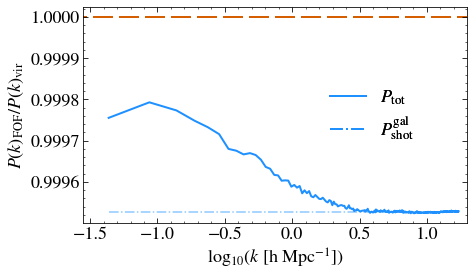

In [26]:
ps.compare_ps_plot([Pk_gal10, Pk_gal10_fof], labels=["vir", "FOF"], residuals_only=True, ratio_ylabel_list=["vir", "FOF"], bbox_to_anchor_grey=(0.6,0.7), bbox_to_anchor_color=(0.3,1), color_list=palette_tab10[3:4] + ["DodgerBlue"], shotnoise_subtracted_ps=False)
#plt.savefig("../figures/vir_vs_fof_ps.pdf", format="pdf", bbox_inches="tight")
#plt.ylim(0.5,1.1)


In [27]:
ks = np.log10(Pk_gal10["k"])

In [ ]:
from matplotlib.patches import Rectangle
fig,ax = plt.subplots()
linewidth1=1
plt.plot([arr_all[0],arr_all[-1]], [1,1], linestyle=(5, (10/linewidth1, 6/linewidth1)), color="k")
#plt.plot(arr, Pks/Pk_gal_all["power"].real[0], label=r"$\rm P_{S} (k=0.04)$")
plt.plot(ks, (Pk_gal10_fof["power"].real)/(Pk_gal10["power"].real), linestyle="solid", label=r"$P_{\mathrm{clus}} (k=0.04)$", c=color_list[3
                                                                                                                                          ])
plt.plot(arr_all, np.array(shot_arr)/Pk_gal10.attrs["shotnoise"], linestyle="dashdot", label=r"P$_{\rm shot}$", c=color_list[3])
plt.plot(arr_all, np.array(group_shot_arr)/Pk_sum10.attrs["shotnoise"], linestyle="dashdot", label=r"P$_{\rm shot}$", c="goldenrod")


#plt.plot(arr_all, (Pks_fof-shot_fof_arr)/(Pk_gal_all["power"].real[ik]-Pk_gal_all.attrs["shotnoise"]), label=r"$\rm P_{S} (k=0.04)$", c=color_list[1])
#plt.plot(arr_all, np.array(shot_fof_arr)/Pk_gal_all.attrs["shotnoise"], linestyle="dashed", label=r"P$_{\rm shot}$", c=color_list[1])

label_list = [r"$M_{\mathrm{vir}} > M_{\mathrm{min}}$"]
solid_lines=[]
for i in range(1):
    solid_line = Line2D([],[],color=color_list[i], linestyle="solid", label=label_list[i])
    solid_lines.append(solid_line)

legend_fontsize=18
first_legend = plt.legend(handles=solid_lines,fontsize=legend_fontsize, frameon=False)
#ax1 = plt.gca().add_artist(first_legend)
shotnoise_ps_leg = Line2D([],[],color=color_list[3], linestyle="dashdot", label=r"$P^{\mathrm{gal}}_{\rm shot}/ P^{\mathrm{gal}}_{\rm shot, all}$")
group_shotnoise_ps_leg = Line2D([],[],color="goldenrod", linestyle="dashdot", label=r"$P^{\mathrm{halo}}_{\rm shot}/ P^{\mathrm{halo}}_{\rm shot, all}$")
shotnoise_subtracted_ps_leg = Line2D([],[],color=color_list[3], linestyle="solid",label=r"$P_{\rm tot}(k=0.04)/P_{\rm tot, all}(k=0.04)$")
intensity_leg = Line2D([],[],color=color_list[3], linestyle="dashed",label=r"$\overline{I}\ /\ \overline{I}_{\rm all}$")

ax = plt.gca()
leg = ax.legend(handles=[intensity_leg],loc = "lower right", bbox_to_anchor=(1,0.45))
ax.add_artist(leg)

bbox_to_anchor_grey = (1,0.3)
leg_list = [shotnoise_ps_leg]
leg1 = plt.legend(handles=leg_list,bbox_to_anchor=bbox_to_anchor_grey,loc="lower right",fontsize=legend_fontsize, frameon=False)
ax.add_artist(leg1)
bbox_to_anchor_grey = (1,0.15)
leg_list = [group_shotnoise_ps_leg]
leg1 = plt.legend(handles=leg_list,bbox_to_anchor=bbox_to_anchor_grey,loc="lower right",fontsize=legend_fontsize, frameon=False)
ax.add_artist(leg1)
bbox_to_anchor_grey = (1,0)
leg_list = [shotnoise_subtracted_ps_leg ]
plt.legend(handles=leg_list,bbox_to_anchor=bbox_to_anchor_grey,loc="lower right",fontsize=legend_fontsize, frameon=False)

plt.xlabel('log$_{10}$($M_\mathrm{max}$ [M$_\odot$ h$^{-1}$])')
plt.ylabel("Ratio")
#plt.ylabel(r"$M > M_{\rm min}/{M > 10^8}$M$_\odot$ h$^{-1}$")
#ax.add_patch(Rectangle((10, 1), 0.5, 0.01, fill=False))
"""
# inset axes....
x1, x2, y1, y2 = 10, 10.6, 1, 1.01  # subregion of the original image
axins = ax.inset_axes(
    [0.1, 0.4, 0.6, 0.6],
    xlim=(x1, x2), ylim=(y1, y2))
axins.plot(arr_all,(Pks-shot_arr)/(Pk_gal_all["power"].real[ik]-Pk_gal_all.attrs["shotnoise"]))

ax.indicate_inset_zoom(axins, edgecolor="black")
"""
#ax.tick_params(length=5)

ax.plot(arr_all, np.array(Pk_means)/Pk_mean_gal10, linestyle="dashed", color=color_list[3])
#plt.savefig("../figures/max_masses.pdf", format="pdf", bbox_inches="tight")

shotnoise:  130.38519438706473
shotnoise:  130.32366594094302


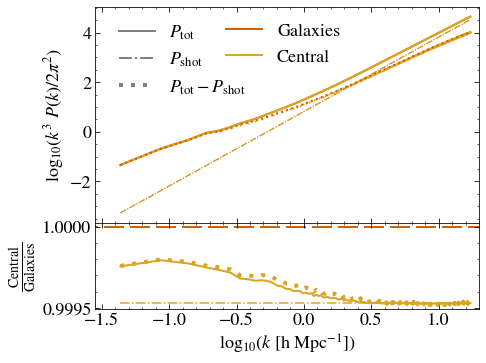

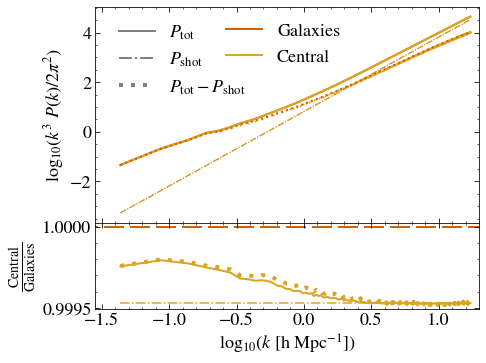

In [14]:
ps.compare_ps_plot([Pk_gal10, Pk_gal10_fof], labels=["Galaxies", "Central"], ratio_ylabel_list=["Galaxies","Central"], bbox_to_anchor_grey=(0.02,1), bbox_to_anchor_color=(0.3,1), shotnoise_subtracted_ps=True, dots4group=True)
#plt.savefig("figures/cent_vs_gal.pdf", format="pdf", bbox_inches="tight")
#plt.ylim(0.5,1.1)

shotnoise:  130.06785491910682
shotnoise:  130.06581484329647


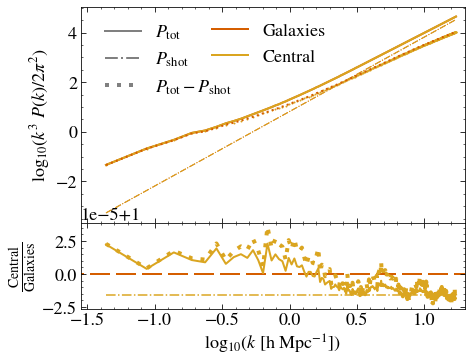

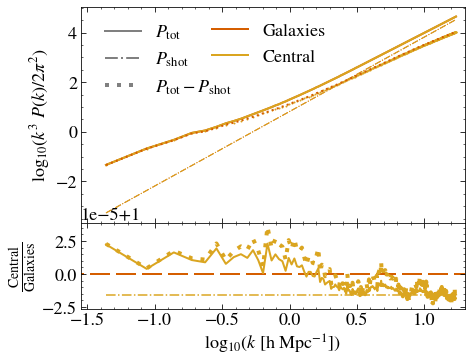

In [16]:
ps.compare_ps_plot([Pk_gal_all, Pk_all_fof], labels=["Galaxies", "Central"], ratio_ylabel_list=["Galaxies","Central"], bbox_to_anchor_grey=(0.02,1), bbox_to_anchor_color=(0.3,1), shotnoise_subtracted_ps=True, dots4group=True)
#plt.savefig("figures/cent_vs_gal.pdf", format="pdf", bbox_inches="tight")
#plt.ylim(0.5,1.1)